# Aula 0 · O seu primeiro notebook

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlexChequer/notebooks-insperai/blob/main/trainees/aula-00-primeiro-notebook.ipynb)

**Trilha de Trainees — InsperAI** · o par prático da [Aula 0](https://trilhas-insperai.vercel.app/trainees/guias/aula-0/)

---

Este é o único notebook do semestre que **não** é sobre machine learning: ele é
sobre a ferramenta. Todos os outros vão assumir que você já sabe o que acontece
aqui.

Ele faz três coisas:

1. **testa a sua máquina** — se a primeira célula rodar, o seu ambiente está pronto;
2. **ensina a mecânica** — célula, kernel, ordem de execução, e como ler um erro;
3. **dá um gostinho** — no fim, uma máquina aprende uma regra que você escondeu dela.

Não precisa ter feito o setup para começar: pelo Colab isto roda no navegador, sem
instalar nada. Mas se você **fez** o setup local, abra este arquivo no VS Code — a
célula abaixo é o teste de que deu certo.

In [1]:
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

# Rodando no Colab, o módulo google.colab já está carregado; na sua máquina, não.
# É o jeito mais barato de saber qual dos dois ambientes está respondendo.
onde = "Google Colab" if "google.colab" in sys.modules else "sua máquina"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print(f"rodando em:   {onde}")
print(f"python        {sys.version.split()[0]}")
print(f"numpy         {np.__version__}")
print(f"pandas        {pd.__version__}")
print(f"matplotlib    {matplotlib.__version__}")
print(f"scikit-learn  {sklearn.__version__}")
print("\nimportou tudo. o ambiente está pronto.")

rodando em:   sua máquina
python        3.13.12
numpy         2.5.2
pandas        3.0.5
matplotlib    3.11.1
scikit-learn  1.9.0

importou tudo. o ambiente está pronto.


Se apareceu a lista de versões aí em cima, **o setup acabou** — é exatamente isso
que a seção "Montar o ambiente" da Aula 0 estava preparando. Se apareceu um bloco
vermelho, vá para a seção 3 deste notebook, que ensina a ler o erro, e leve a
mensagem para a aula.

## 1 · A célula é a unidade de tudo

Um notebook é uma pilha de **células**, e existem dois tipos:

- **célula de código** — Python que roda. É a que tem um `[ ]` do lado esquerdo.
- **célula de markdown** — texto, como este que você está lendo. Não executa nada.

Para rodar a célula onde o cursor está: **`Shift + Enter`**. Ele executa e pula para
a próxima. (`Ctrl + Enter` executa e fica onde está — útil para repetir a mesma.)

Clique na célula abaixo e aperte `Shift + Enter`.

In [2]:
2 + 2

4

Apareceu um `4` embaixo. Repare que **ninguém mandou imprimir nada**: o notebook
mostra sozinho o valor da **última linha** da célula. É um atalho que só existe
aqui, e é por isso que tanto notebook termina em `tabela.head()` ou no nome de uma
variável solta — é a forma mais curta de espiar um resultado.

Só a **última** linha, no entanto. As de cima somem, a menos que você peça `print`:

In [3]:
10 * 3   # esta some: não é a última linha e ninguém imprimiu
print("esta aparece, porque foi impressa")
7 - 5    # esta aparece, porque é a última

esta aparece, porque foi impressa


2

## 2 · O kernel: a memória do notebook

Por trás do arquivo existe um **kernel** — um Python ligado, esperando ordens. É
ele que executa as células, e ele **lembra** de tudo o que já rodou.

Por isso uma variável criada numa célula continua viva na seguinte:

In [4]:
turma = "InsperAI 2026"
alunos = 40

In [5]:
# Outra célula, e o kernel ainda lembra das duas variáveis de cima.
print(f"{turma} tem {alunos} alunos")

InsperAI 2026 tem 40 alunos


### O número do lado é a ordem de execução

Depois de rodar, o `[ ]` vira `[1]`, `[2]`, `[3]`… Esse contador **não** diz a
posição da célula no arquivo: ele diz **em que ordem** o kernel executou. Um `[ ]`
vazio quer dizer "esta célula nunca rodou nesta sessão"; um `[*]`, "está rodando
agora".

Guarde isso, porque é a origem da armadilha mais comum do notebook.

🔬 **Experimente:** rode a célula abaixo **três vezes seguidas** (`Ctrl + Enter`,
três vezes) e olhe o resultado e o número do lado.

In [6]:
contador = 10

In [7]:
contador = contador * 2
print(contador)

20


Ele dobra a cada vez: 20, 40, 80. A célula é a mesma e o código é o mesmo — o que
mudou foi o **estado** guardado no kernel. Rodar de novo não é começar de novo.

Daí a armadilha: **a ordem em que você rodou não é a ordem em que está escrito.**
Você mexe numa célula lá em cima, roda só ela, e o notebook passa a exibir uma
saída que ninguém conseguiria reproduzir lendo o arquivo de cima para baixo — nem
você, amanhã.

> **A regra de ouro do notebook:** antes de entregar ou de acreditar num resultado,
> faça **Restart & Run All**. Isso desliga o kernel, apaga a memória inteira e roda
> tudo na ordem escrita. Se quebrar aí, já estava quebrado — você só não estava
> vendo.

No VS Code são os botões **Restart** e **Run All**, no topo do notebook. No Colab,
menu **Ambiente de execução → Reiniciar sessão e executar tudo**.

## 3 · Quando der erro (e vai dar)

Erro em notebook não é sinal de que você não leva jeito: é o funcionamento normal
da coisa, todo dia, para todo mundo. O que separa quem trava de quem resolve é
**ler a mensagem** em vez de fechar os olhos para ela.

Vamos provocar um de propósito. A Aula 0 avisa que a contagem de uma lista começa
no **zero** — então uma lista de 3 itens tem as posições 0, 1 e 2, e a 3 não existe:

In [8]:
import traceback

precos = [250, 310, 180]

try:
    print(precos[3])   # não existe: as posições são 0, 1 e 2
except IndexError:
    # O try/except está aqui só para o notebook conseguir rodar até o fim. No seu
    # dia a dia o erro aparece assim mesmo, em vermelho, e interrompe tudo.
    traceback.print_exc()

Traceback (most recent call last):
  File "/var/folders/nm/6_lrgc0973lg4q70dttwtf4w0000gn/T/ipykernel_4603/2465589064.py", line 6, in <module>
    print(precos[3])   # não existe: as posições são 0, 1 e 2
          ~~~~~~^^^
IndexError: list index out of range


Um erro do Python tem três partes, e se lê **de baixo para cima**:

1. **A última linha é a resposta.** `IndexError: list index out of range` — "você
   pediu uma posição que a lista não tem". É essa linha que se joga no Google ou se
   cola no chat da IA, não o bloco inteiro.
2. **Logo acima aparece o código culpado**, com uma seta apontando para ele.
3. **O miolo é o caminho** até lá — o *traceback*. Quando o erro nasce dentro de uma
   biblioteca, ele fica comprido, e a parte que interessa é a que menciona código
   **seu**.

Aquele nome de arquivo esquisito no meio do caminho — algo como
`.../ipykernel_1234/5678901.py` — é a **própria célula**: para executar, o notebook
salva o que você escreveu num arquivo temporário, de nome sorteado. Não é erro seu e
não quer dizer nada; pode ignorar.

Os nomes que você mais vai encontrar:

| erro | o que quer dizer |
|---|---|
| `NameError` | usou um nome que não existe — quase sempre porque a célula que o criava não rodou |
| `IndexError` / `KeyError` | pediu uma posição, ou uma coluna, que não existe |
| `ValueError: ... shape ...` | dois dados com formatos que não combinam — **o clássico de ML** |

> **`NameError` num notebook é quase sempre um problema de ordem, não de código.**
> Antes de sair caçando o bug, faça Restart & Run All.

## 4 · Um gostinho: a máquina achando uma regra

Você já tem a mecânica. Agora, para ver onde ela vai dar, um exemplo de machine
learning inteiro — do dado ao modelo — em poucas células.

O truque para enxergar o que acontece é este: **nós é que vamos inventar a regra.**
Depois escondemos ela dentro de um monte de números bagunçados e perguntamos se o
computador consegue achá-la de volta.

A regra inventada, sobre horas de estudo e nota de prova:

$$\text{nota} = 4{,}0 + 0{,}8 \times \text{horas}$$

Ou seja: quem não estudou nada tira 4, e cada hora de estudo vale 0,8 ponto a mais.
Só que a vida não é limpa assim — tem quem durma mal, tem quem tenha sorte na
prova —, então cada aluno leva também um empurrão aleatório, para cima ou para
baixo.

In [9]:
# A semente fixa faz o "aleatório" sair igual em toda execução. Sem ela, os números
# mudariam a cada rodada e o texto deste notebook deixaria de bater com a saída.
rng = np.random.default_rng(42)

INTERCEPTO_REAL = 4.0   # a nota de quem não estudou nada
INCLINACAO_REAL = 0.8   # quanto vale cada hora de estudo

horas = rng.uniform(0, 6, size=40).round(1)
ruido = rng.normal(0, 0.7, size=40)                       # o acaso da vida
notas = (INTERCEPTO_REAL + INCLINACAO_REAL * horas + ruido).round(1)

alunos = pd.DataFrame({"horas_estudo": horas, "nota": notas})
alunos.head()

,horas_estudo,nota
0,4.6,8.2
1,2.6,6.5
2,5.2,7.7
3,4.2,7.5
4,0.6,4.6


Uma tabela dessas se chama **DataFrame**, e é o formato em que quase todo dado
tabular chega no Python. O `head()` mostra só as cinco primeiras linhas; o resto
continua lá.

Antes de qualquer modelo, os dois números que a Aula 0 apresentou — a **média** (o
valor típico) e o **desvio padrão** (o quanto os valores se afastam dela) — e o
**formato** (`shape`): quantas linhas e quantas colunas.

In [10]:
print(f"formato da tabela:  {alunos.shape}   (linhas, colunas)")
print(f"nota média:         {notas.mean():.2f}")
print(f"desvio padrão:      {notas.std():.2f}")
print(f"da menor à maior:   {notas.min():.1f} a {notas.max():.1f}")

formato da tabela:  (40, 2)   (linhas, colunas)
nota média:         6.58
desvio padrão:      1.34
da menor à maior:   3.9 a 8.9


Agora olhe os alunos num gráfico. Cada ponto é uma pessoa: a posição horizontal são
as horas que ela estudou, e a vertical, a nota que tirou.

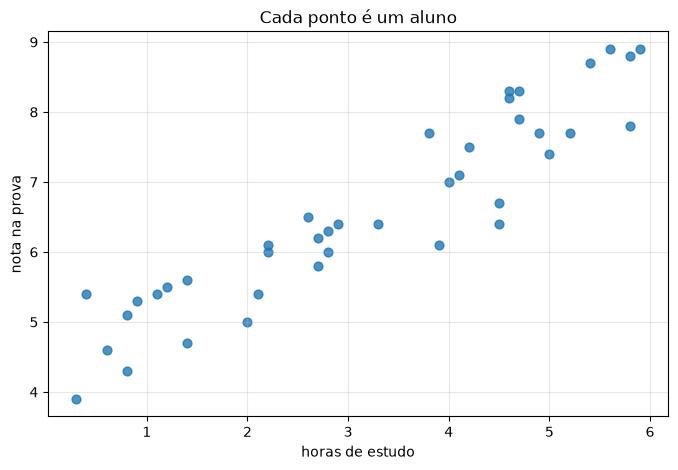

In [11]:
plt.scatter(horas, notas, s=40, alpha=0.8)
plt.xlabel("horas de estudo")
plt.ylabel("nota na prova")
plt.title("Cada ponto é um aluno")
plt.show()

Os pontos **não** formam uma reta — formam uma **tendência**: sobem da esquerda para
a direita, com bagunça em volta. Foi o ruído que fez a bagunça, e nós sabemos disso
porque fomos nós que o colocamos ali.

A pergunta do machine learning é: **olhando só para os pontos, dá para recuperar a
regra?** Ninguém contou ao computador que o intercepto é 4,0 e a inclinação é 0,8 —
ele recebe a nuvem e mais nada.

In [12]:
from sklearn.linear_model import LinearRegression

# O sklearn espera as entradas como uma tabela — linhas são exemplos, colunas são
# features —, não como uma lista solta. Daí o reshape: 40 alunos, 1 feature cada.
X = horas.reshape(-1, 1)

modelo = LinearRegression()
modelo.fit(X, notas)      # esta linha é o "treino". É ela o machine learning.

inclinacao_aprendida = modelo.coef_[0]
intercepto_aprendido = modelo.intercept_

print(f"{'':<14}{'inventamos':>12}{'ele achou':>12}")
print(f"{'intercepto':<14}{INTERCEPTO_REAL:>12.2f}{intercepto_aprendido:>12.2f}")
print(f"{'inclinação':<14}{INCLINACAO_REAL:>12.2f}{inclinacao_aprendida:>12.2f}")

                inventamos   ele achou
intercepto            4.00        4.23
inclinação            0.80        0.73


Perto. Não exato — e **não deveria** ser exato: o computador não viu a regra, viu 40
pontos embaçados pelo ruído. Ele reconstruiu o que dava para reconstruir a partir
deles.

É machine learning inteiro, em miniatura: existe uma regra no mundo, você só tem
observações sujas dela, e o modelo é a melhor reconstrução possível a partir dessas
observações.

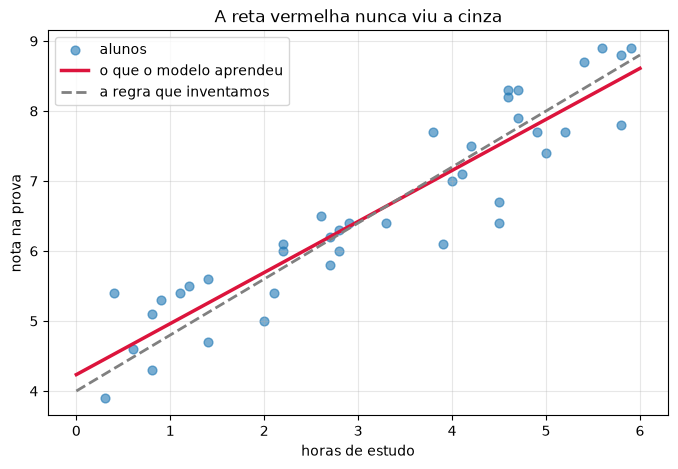

In [13]:
linha_x = np.array([[0], [6]])

plt.scatter(horas, notas, s=40, alpha=0.6, label="alunos")
plt.plot(linha_x, modelo.predict(linha_x), color="crimson", lw=2.5,
         label="o que o modelo aprendeu")
plt.plot([0, 6], [INTERCEPTO_REAL, INTERCEPTO_REAL + INCLINACAO_REAL * 6],
         color="gray", ls="--", lw=2, label="a regra que inventamos")
plt.xlabel("horas de estudo")
plt.ylabel("nota na prova")
plt.legend()
plt.title("A reta vermelha nunca viu a cinza")
plt.show()

As duas quase se encostam. A cinza é a verdade que escondemos; a vermelha saiu
**só** dos pontos.

E um modelo serve justamente para responder sobre quem ainda não apareceu:

In [14]:
for h in [1, 3, 5]:
    previsao = modelo.predict(np.array([[h]]))[0]
    print(f"quem estudar {h}h deve tirar por volta de {previsao:.1f}")

quem estudar 1h deve tirar por volta de 5.0
quem estudar 3h deve tirar por volta de 6.4
quem estudar 5h deve tirar por volta de 7.9


Três ressalvas honestas, para você não sair daqui achando demais:

- **O dado é inventado.** Nós plantamos a relação, então era garantido que ela
  estivesse lá. Com dado de verdade não há garantia nenhuma — o notebook da Aula 1
  usa 1.460 imóveis reais, e a nuvem lá é bem mais teimosa que esta.
- **Achar uma relação não é achar uma causa.** O modelo diz que nota e horas de
  estudo andam juntas. Ele não diz, e não pode dizer, que estudar *causa* a nota.
- **Você viu o modelo aprender, não *como* ele aprendeu.** Aquele `modelo.fit()` é
  uma caixa fechada por enquanto. Abrir a caixa — descobrir como o computador
  procura a melhor reta — é literalmente a Aula 1.

---

## 🔬 Desafio

Três exercícios. Tente antes de abrir a resposta — e se quebrar alguma coisa, ótimo:
Restart & Run All conserta.

**1.** O ruído era `0.7`. Refaça o dado com `2.5` — muito mais bagunça — e veja se o
modelo ainda acha a regra.

<details><summary>Resposta</summary>

```python
r = np.random.default_rng(42)
h_ruidoso = r.uniform(0, 6, size=40)
n_ruidoso = INTERCEPTO_REAL + INCLINACAO_REAL * h_ruidoso + r.normal(0, 2.5, size=40)

barulhento = LinearRegression().fit(h_ruidoso.reshape(-1, 1), n_ruidoso)
print(f"inclinação: inventamos {INCLINACAO_REAL:.2f}, ele achou {barulhento.coef_[0]:.2f}")
print(f"intercepto: inventamos {INTERCEPTO_REAL:.2f}, ele achou {barulhento.intercept_:.2f}")
```

Ele continua achando *mais ou menos*, e erra bem mais. Quanto mais barulho existe no
dado, mais observações são necessárias para enxergar a mesma regra através dele — e
essa é uma das razões de datasets grandes valerem tanto.
</details>

**2.** Em vez de mais ruído, use **menos alunos**: `size=5`. Rode com algumas
sementes diferentes e compare as inclinações encontradas — todas vêm da mesma regra.

<details><summary>Resposta</summary>

```python
for n_alunos in (5, 40):
    achados = []
    for semente in range(1, 7):
        r = np.random.default_rng(semente)
        h = r.uniform(0, 6, size=n_alunos)
        n = INTERCEPTO_REAL + INCLINACAO_REAL * h + r.normal(0, 0.7, size=n_alunos)
        achados.append(LinearRegression().fit(h.reshape(-1, 1), n).coef_[0])
    print(f"{n_alunos:>2} alunos:", "  ".join(f"{a:.2f}" for a in achados))
```

```
 5 alunos: 0.71  0.79  0.55  1.02  0.52  0.88
40 alunos: 0.72  0.82  0.82  0.93  0.82  0.80
```

Com 5 alunos a inclinação vai de **0,52 a 1,02** — quase o dobro, para a mesma regra
de sempre. Com 40 ela quase não sai de perto de 0,8.

O dado é pouco, então o modelo está lendo tanto o acaso quanto a regra, e não tem
como distinguir um do outro. Sempre que alguém mostrar um resultado impressionante,
a primeira pergunta é **quantos exemplos** — e a segunda é o que aconteceria se
fossem outros.
</details>

**3.** Rode `modelo.predict(5)` — sem os colchetes. Leia o erro até o fim e conserte.

<details><summary>Resposta</summary>

O bloco é comprido, mas a última linha entrega o caso:

> `ValueError: Expected 2D array, got scalar array instead`

O `predict` quer uma **tabela** de exemplos, não um número solto: linhas são alunos,
colunas são features. Um aluno com uma feature ainda é uma tabela — de 1 por 1.

```python
print(modelo.predict(np.array([[5]]))[0])
```

Erro de **formato** é o mais comum ao rodar notebook de ML, e o sklearn é educado:
ele diz o que esperava (`2D array`) e o que recebeu (`scalar`). Ler as duas metades
resolve quase sempre.
</details>

---

## O que ficou

- **A célula é a unidade**, e `Shift + Enter` roda. A última linha aparece sozinha.
- **O kernel lembra.** Uma variável criada numa célula vive nas outras — e rodar a
  mesma célula de novo continua de onde parou, não recomeça.
- **A ordem que vale é a de execução**, não a da tela. Antes de acreditar num
  resultado: **Restart & Run All**.
- **Erro se lê de baixo para cima.** A última linha é a resposta; `NameError` quase
  sempre é ordem de execução, e formato quase sempre é `shape`.
- **Treinar é reconstruir uma regra a partir de observações sujas** — e a
  reconstrução não sai exata, o que é o esperado e não um defeito.

**Próximo:** [Aula 1 — Intro a ML + Regressão Linear](https://colab.research.google.com/github/AlexChequer/notebooks-insperai/blob/main/trainees/aula-01-regressao-linear.ipynb),
onde os pontos são 1.460 imóveis de verdade e o `fit()` deixa de ser uma caixa
fechada: você escreve as contas que ele faz por dentro.